# Import libraries

In [53]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [54]:
c = 299792.458 #is this in the correct units?
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)
megaparsec = 3.0856775814913673 * 10**10

# Some key functions

In [55]:
#order of variables: z, omega_k, omega_M, omega_DE, H0, rc

def eos(z, w):
    return w[0] + w[1]*(np.log(2+z)/(1+z) - np.log(2))

def Friedmann_eq2(z, theta):
    omega_k, omega_DE, H0, w0, w1 = theta
    w = eos(z, [w0, w1])
    omega_M = 1 - omega_k - omega_DE
    H2 = (omega_M*(1+z)**3 + omega_DE*(1+z)**(3*(1+w)) - omega_k*(1+z)**2)
    #print(H2)
    return H2

def integrand(z, theta):
    return 1/np.sqrt(Friedmann_eq2(z, theta))

def co_moving_dist(z_up, theta):
    z_up = np.concatenate(([0], z_up))
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, theta), 0, z_up)
    r_c = np.delete(r_cm, 0)
    return np.ndarray.flatten(r_c)

def Sk(omega_k, H0, rc): #units issue?
    if omega_k == 0:
        return c*rc/H0
    if omega_k < 0:
        return (c/(H0*np.sqrt(-omega_k)))*np.sin(np.sqrt(-omega_k)*rc)
    return (c/(H0*np.sqrt(omega_k)))*np.sinh(np.sqrt(omega_k)*rc)

def dist_modulus(z, theta):
    omega_k = theta[0]
    H0 = theta[2]
    #print(f"H0 is {H0}")
    rc = co_moving_dist(z, theta)
    s_k = Sk(omega_k, H0, rc)
    dl = (1+z)*s_k
    #if not np.all(dl>0):
        #print(f"luminosity distance isn't positive, params are: {theta}\n")
        #for i in range(len(dl)):
            #print(f"{dl[i]}, {s_k[i]}, {rc[i]}")
    dist_mod = 5*np.log10(dl) + 25
    return dist_mod

# Load the data

In [56]:
sn_z, sn_z_err, sn_mu, sn_mu_err = np.loadtxt("pantheon-plus+SH0ES-SN.txt", usecols=(2,3,4,5), unpack = True)
covmat_file = np.loadtxt("Pantheon+SH0ES_STAT+SYS.cov")
covmat_file_dim = int(covmat_file[0])
covmat_file = np.delete(covmat_file, 0)
covmat = np.zeros((covmat_file_dim, covmat_file_dim))
covmat.shape
for i in range(covmat_file_dim):
    covmat[i] = covmat_file[i*covmat_file_dim:(i+1)*covmat_file_dim]
covmat_inv = np.linalg.inv(covmat)


## Priors

Parameters of model are: {k, H0, omega_M, omega_DE}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [57]:
H0_prior = 73.3
H0_stdev_prior = 1.04
omega_DE_prior = 0.6889
omega_DE_stdev_prior = 0.0056

def log_prior(theta, z):
    omega_k, omega_DE, H0, w0, w1 = theta
    H2 = Friedmann_eq2(z, theta)
    if not (-1<omega_k<1 and np.all(H2>0) and -3<w0<3 and 20<H0<100 and -20<w1<80):
        return -np.inf
    return -0.5*(omega_DE-omega_DE_prior)**2/omega_DE_stdev_prior**2

nparams = 5
nwalkers = 32
pos = np.zeros((nwalkers, nparams))
for i in range(len(pos)):
    pos[i][0] = np.random.uniform(-0.005, 0.005)
    pos[i][1] = np.random.uniform(0.6, 0.75)
    pos[i][2] = np.random.uniform(20, 100)
    pos[i][3] = np.random.uniform(-2,-0.01)
    pos[i][4] = np.random.uniform(-4,9)
    

# Likelihood function

In [58]:
def log_likelihood(theta, z, mu, covmatrix_inv):
    model = dist_modulus(z, theta)
    resids = mu - model
    chi2 = np.matmul(np.matmul(resids, covmatrix_inv), resids)
    return -0.5*chi2
    


def log_probability(theta, z, mu, covmatrix_inv):
    lp = log_prior(theta, z)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, covmatrix_inv)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [59]:
nsteps = 1000 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler2 = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mu, covmat_inv)
)
sampler2.run_mcmc(pos, nsteps, progress = True)

100%|██████████| 1000/1000 [02:25<00:00,  6.89it/s]


State([[-2.63484938e-01  6.84810331e-01  5.75803850e+01  1.12746165e-01
   3.27685601e+01]
 [-6.08694673e-02  6.81781704e-01  6.87223193e+01 -9.83834159e-01
   5.89020809e-01]
 [-3.06602580e-01  6.90140387e-01  5.63281759e+01  2.87552997e-01
   4.37362692e+01]
 [-1.28093387e-01  6.82333083e-01  6.44203328e+01 -6.98364904e-01
   8.20775418e+00]
 [-4.49185861e-01  6.88341468e-01  5.17397202e+01  3.11672801e-02
   4.31281356e+01]
 [-1.21706210e-01  6.96883637e-01  6.52718942e+01 -7.75605092e-01
   7.52065913e+00]
 [-3.49688990e-01  6.94835213e-01  5.47837740e+01  1.49464527e-02
   3.49909620e+01]
 [-2.09265530e-01  6.92607808e-01  6.06634762e+01 -6.34036750e-01
   1.28237549e+01]
 [ 1.15498895e-01  6.95264199e-01  8.30916198e+01 -7.06676597e-01
  -3.40692324e-01]
 [-4.07186955e-01  6.82917526e-01  5.28622898e+01  3.68431814e-01
   4.92557918e+01]
 [-4.86820764e-01  6.88796932e-01  5.02523014e+01  7.62414989e-01
   5.71865834e+01]
 [-3.29133176e-01  6.90526710e-01  5.56711408e+01 -4.821529

autocorrelation time is [1762.7379727   178.15626109 2091.34348738  666.2545842   996.93581744]


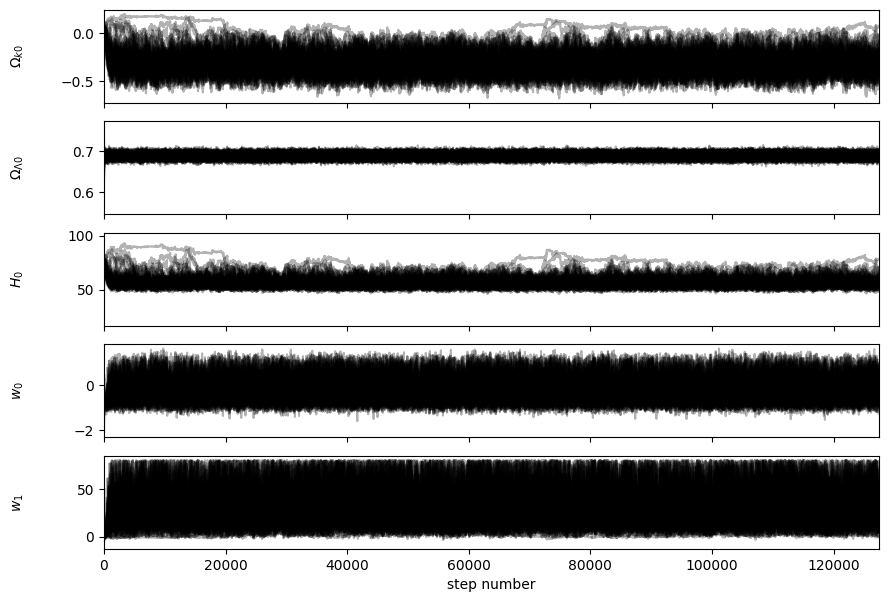

In [83]:
#sampler2.run_mcmc(None, 20000, progress = True)
ndiscard = 1800 #how many steps at the beginning of the chain to discard
#flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(nparams, figsize=(10, 7), sharex=True)
samples = sampler2.get_chain()
labels = ["$Ω_{k0}$", "$Ω_{Λ0}$", "$H_{0}$", "$w_{0}$", "$w_{1}$"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.savefig("walkers_logCDM.png")
print(f"autocorrelation time is {sampler2.get_autocorr_time()}")

# Covariance plots

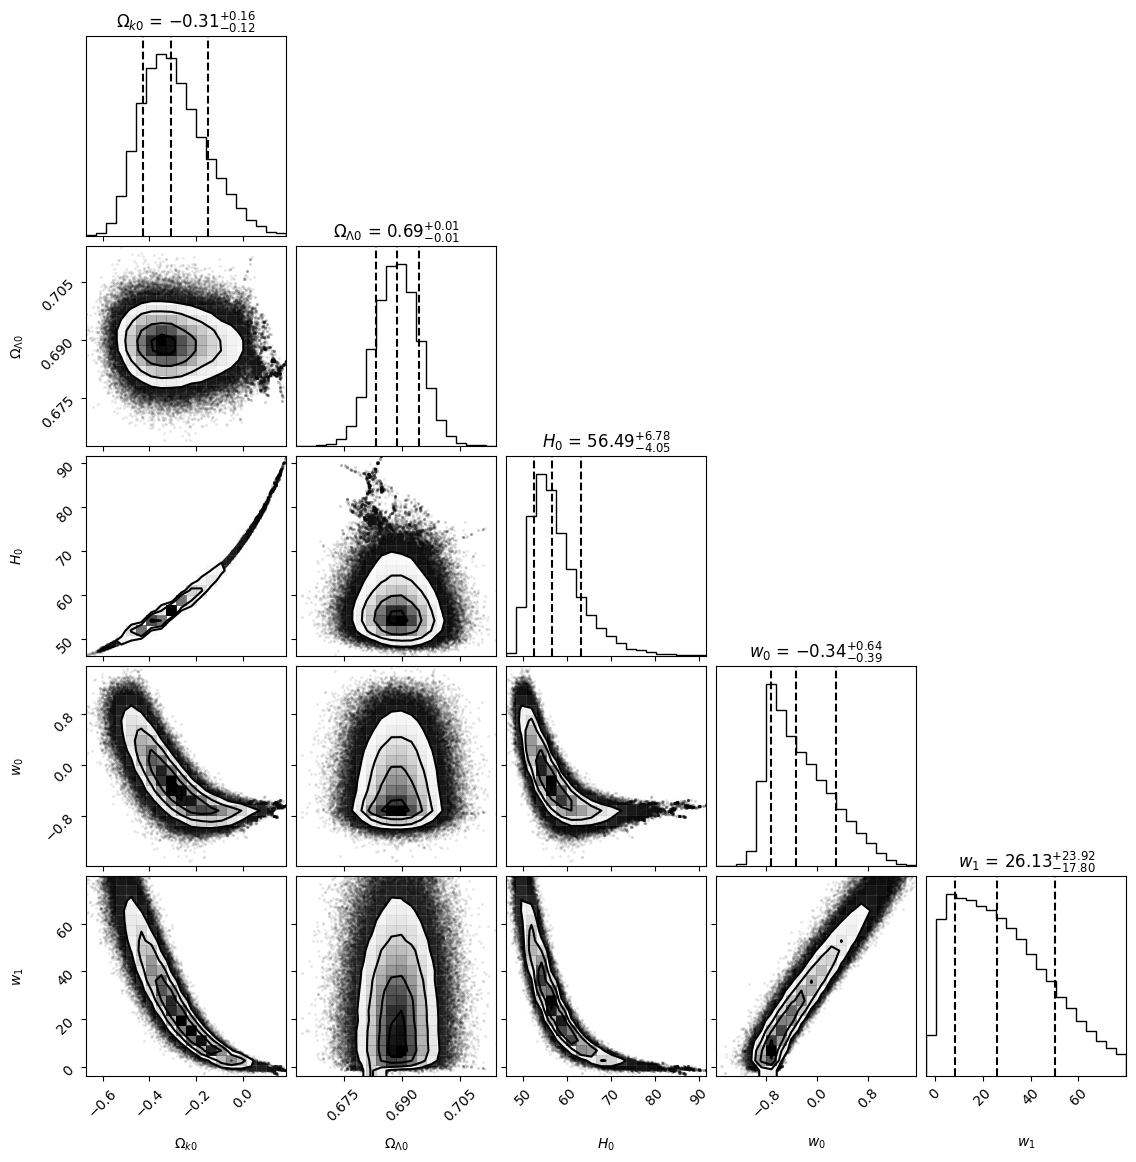

In [82]:
#sampler2.run_mcmc(None, 20000, progress = True)
flat_samples = sampler2.get_chain(discard = 9000, thin = 15, flat = True)
fig = corner.corner(
    flat_samples, labels = labels, quantiles=[0.16,0.5,0.84], show_titles=True, title_kwargs={"fontsize": 12}
)
plt.savefig("corner_logCDM.png")

In [78]:
with open("flat_samples_logCDM_long.txt", "a") as f:
    f.write(str(list(flat_samples)))
with open("all_samples_logCDM.txt", "a") as file2:
    sample_long = sampler2.get_chain(flat = True)
    file2.write(str(list(sample_long)))

In [75]:
sampler2.run_mcmc(None, 50000, progress = True)

 76%|███████▌  | 37980/50000 [1:10:10<15:16, 13.12it/s]

emcee: Exception while calling your likelihood function:
  params: [-0.53078362  0.68165594 48.93149684  0.29235029 64.14776242]
  args: (array([1.22000e-03, 1.22000e-03, 2.56000e-03, ..., 1.80119e+00,
       1.91165e+00, 2.26137e+00]), array([28.9987, 29.0559, 30.7233, ..., 45.4865, 45.4233, 46.1828]), array([[ 3.35405114e+01, -5.68645204e+00, -1.07870284e-01, ...,
         1.44562418e-02,  1.73619146e-02,  6.56463541e-02],
       [-5.68645201e+00,  3.26679150e+01,  6.27809019e-01, ...,
         5.90524514e-02,  5.86751704e-02,  9.18237282e-02],
       [-1.07870328e-01,  6.27808965e-01,  5.66302667e+01, ...,
         4.04987268e-02,  6.08045796e-02,  1.44339360e-01],
       ...,
       [ 1.44562147e-02,  5.90524254e-02,  4.04987139e-02, ...,
         2.64804296e+01, -2.56390503e-01, -5.18344051e-01],
       [ 1.73618976e-02,  5.86751545e-02,  6.08045714e-02, ...,
        -2.56390503e-01,  1.63294720e+01, -4.65796138e-01],
       [ 6.56463083e-02,  9.18236857e-02,  1.44339335e-01, ...,

Traceback (most recent call last):
  File "C:\Users\milan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Temp\ipykernel_28020\3231594283.py", line 10, in log_probability
    lp = log_prior(theta, z)
         ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Temp\ipykernel_28020\1414992533.py", line 9, in log_prior
    if not (-1<omega_k<1 and np.all(H2>0) and -3<w0<3 and 20<H0<100 and -20<w1<80):
                             ^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py", line 2416, in _all_dispatcher
    def _all_dispatcher(a, axis=None, out=None, keepdims=None, *,
    
KeyboardInterrupt
 76%|

KeyboardInterrupt: 

In [79]:


for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]} + {q[1]} - {q[0]}")

$Ω_{k0}$: -0.30728966858657547 + 0.15655063616176138 - 0.11895532177364987
$Ω_{Λ0}$: 0.6888131789837408 + 0.005628254642069286 - 0.0055739073174880804
$H_{0}$: 56.48670923391855 + 6.7839942256618215 - 4.047947275065681
$w_{0}$: -0.33964734198621593 + 0.6350313208864333 - 0.3900610793950189
$w_{1}$: 26.13370154511532 + 23.915640448652493 - 17.79966274446579


In [80]:
theta_model = np.zeros(nparams)
for i in range(nparams):
    theta_model[i] = np.percentile(flat_samples[:, i], [50])[0]

chi-squared: 1748.547158265137


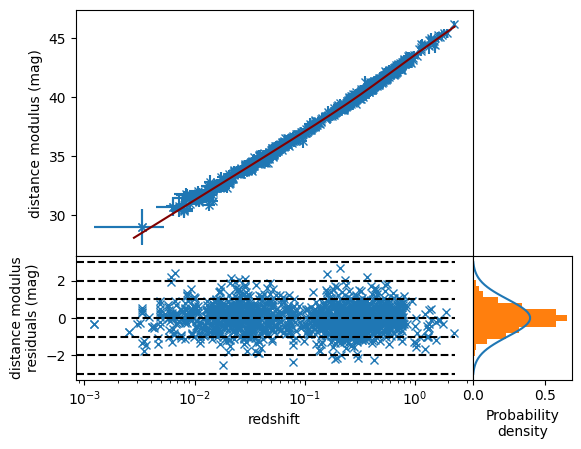

BIC: 1785.7420162271164


In [81]:
model_z = np.linspace(0.001, 2.3, 1000)
model_mu = dist_modulus(model_z, theta_model)
resids = sn_mu - dist_modulus(sn_z, theta_model)
chisqval = np.matmul(np.matmul(resids, covmat_inv), resids)


fig, axs = plt.subplots(2, 2, width_ratios=[4,1], height_ratios=[2,1])
axs[0,0].plot(model_z, model_mu, color = "maroon", zorder = 2)

axs[0,0].errorbar(sn_z, sn_mu, xerr=sn_z_err, yerr = sn_mu_err, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(2,0,2.3, linestyle = "--", color = "black")
norm_resids = (dist_modulus(sn_z, theta_model) - sn_mu)/sn_mu_err
print(f"chi-squared: {chisqval}")
axs[1,0].errorbar(sn_z, norm_resids, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-2,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(0,0,2.3, linestyle = "--", color = "black", zorder = 2)
axs[1,0].set_xlabel("redshift")
axs[0,0].set_ylabel("distance modulus (mag)")
axs[1,0].set_ylabel("distance modulus\nresiduals (mag)")
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)
#axs[0,0].invert_yaxis()
axs[0,0].set_xscale("log")
axs[1,0].set_xscale("log")
axs[0,1].remove()
axs[1,1].get_yaxis().set_visible(False)
xs = np.linspace(-3,3)
axs[1,1].plot(scp.stats.norm.pdf(xs, 0, 1), xs)
axs[1,1].set_xlabel("Probability\ndensity")
axs[1,1].hist(norm_resids, density = True, orientation = u'horizontal', bins = np.linspace(-3, 3, 20))
plt.savefig("plot_logCDM", bbox_inches = "tight")
plt.show()
BIC = nparams*np.log(covmat_file_dim) + chisqval
print(f"BIC: {BIC}")